Linear Regression: Next-Day Energy Prediction

In [3]:
#Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [4]:
# 📥 Step 2: Load and Prepare Data
df = pd.read_csv("ev_energy_with_weather.csv")

# Convert 'date' to datetime and sort by time
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')


In [5]:
# 🧠 Step 3: Feature Engineering

# Add lag and rolling features
df['day_of_week'] = df.index.dayofweek                         # Day of the week (0=Mon, 6=Sun)
df['lag_1_energy'] = df['energy'].shift(1)                     # Yesterday’s energy
df['rolling_energy_7d'] = df['energy'].rolling(7).mean().shift(1)  # 7-day avg (no leakage)
df['rolling_energy_14d'] = df['energy'].rolling(14).mean().shift(1) # 14-day avg (no leakage)

# Target: energy consumption for next day
df['target_energy_t_plus_1'] = df['energy'].shift(-1)

# Remove rows with NaN values (from shift/rolling)
df = df.dropna()


In [6]:
# 🎯 Step 4: Define Features and Target
top_features = ['rolling_energy_7d', 'rolling_energy_14d', 'lag_1_energy', 'day_of_week']
X = df[top_features]
y = df['target_energy_t_plus_1']


In [7]:
# 🔀 Step 5: Time-Aware Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # Don't shuffle time series data!
)


In [8]:
# 🧼 Step 6: Scale the Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [9]:
# 🤖 Step 7: Train Linear Regression Model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)


LinearRegression()

In [10]:
# 📈 Step 8: Predict and Evaluate
y_pred = lr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"📏 MAE:  {mae:.2f}")
print(f"📐 RMSE: {rmse:.2f}")
print(f"📉 R²:   {r2:.4f}")


📏 MAE:  170.95
📐 RMSE: 254.83
📉 R²:   0.0787


In [11]:
df.head()

,energy,t_max,t_min,precip,snow,snow_depth,day_of_week,lag_1_energy,rolling_energy_7d,rolling_energy_14d,target_energy_t_plus_1
date,,,,,,,,,,,
2018-01-15,4.099,38,16,0.06,1.7,2,0,13.798,39.287429,30.450429,70.312
2018-01-16,70.312,36,0,0.00,0.0,1,1,4.099,36.378714,30.278643,44.852
2018-01-17,44.852,52,14,0.00,0.0,0,2,70.312,39.880143,34.049000,51.591
2018-01-18,51.591,63,24,0.00,0.0,0,3,44.852,39.567857,36.450786,34.904
2018-01-19,34.904,69,38,0.00,0.0,0,4,51.591,38.312286,36.582429,30.095


C:\Users\KHALIL\AppData\Local\Temp\ipykernel_300\393881318.py:22: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KHALIL\AppData\Local\Temp\ipykernel_300\393881318.py:22: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\KHALIL\anaconda3\envs\evforecast\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KHALIL\anaconda3\envs\evforecast\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


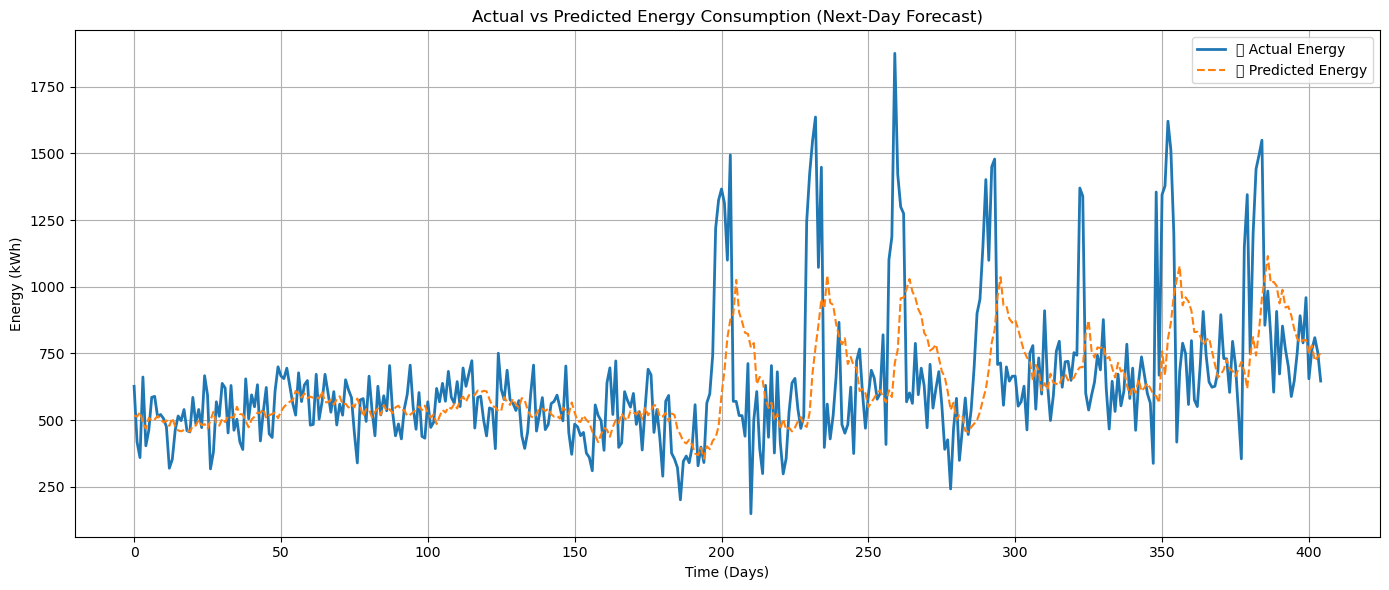

In [12]:
import matplotlib.pyplot as plt

# Step 1: Align index with test set
y_test_indexed = y_test.reset_index(drop=True)
y_pred_indexed = pd.Series(y_pred, name='Predicted')

# Step 2: Combine actual and predicted for plotting
results_df = pd.DataFrame({
    'Actual': y_test_indexed,
    'Predicted': y_pred_indexed
})

# Step 3: Plot
plt.figure(figsize=(14, 6))
plt.plot(results_df['Actual'], label='📈 Actual Energy', linewidth=2)
plt.plot(results_df['Predicted'], label='🔮 Predicted Energy', linestyle='--')
plt.title("Actual vs Predicted Energy Consumption (Next-Day Forecast)")
plt.xlabel("Time (Days)")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\KHALIL\AppData\Local\Temp\ipykernel_300\3943165624.py:27: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KHALIL\AppData\Local\Temp\ipykernel_300\3943165624.py:27: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


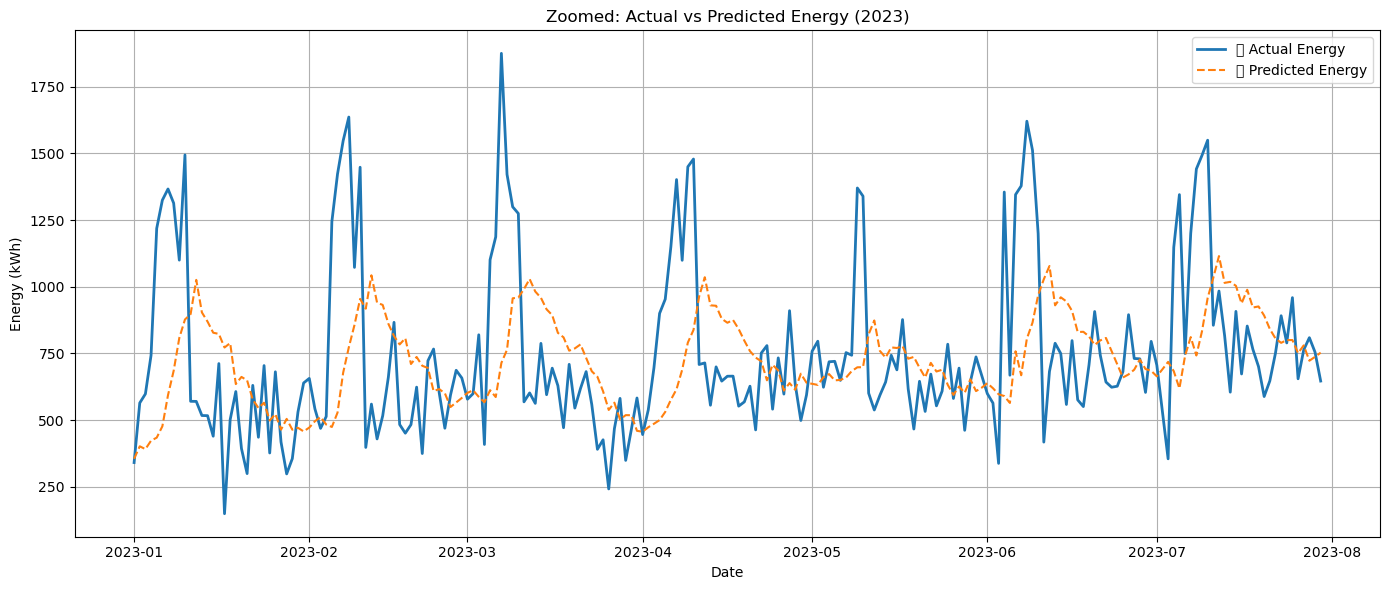

In [13]:
#Zoom into a Specific Date Range (2023 only)
#This version overlays actual vs predicted for just the year 2023:


# Reconstruct full test index with dates if needed
test_index = df.iloc[-len(y_test):].index

# Create full DataFrame with date, actual, predicted
results_2023 = pd.DataFrame({
    'Date': test_index,
    'Actual': y_test.values,
    'Predicted': y_pred
})

# Filter to 2023 only
results_2023 = results_2023[results_2023['Date'].dt.year == 2023]

# Plot
plt.figure(figsize=(14, 6))
plt.plot(results_2023['Date'], results_2023['Actual'], label='📈 Actual Energy', linewidth=2)
plt.plot(results_2023['Date'], results_2023['Predicted'], label='🔮 Predicted Energy', linestyle='--')
plt.title("Zoomed: Actual vs Predicted Energy (2023)")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

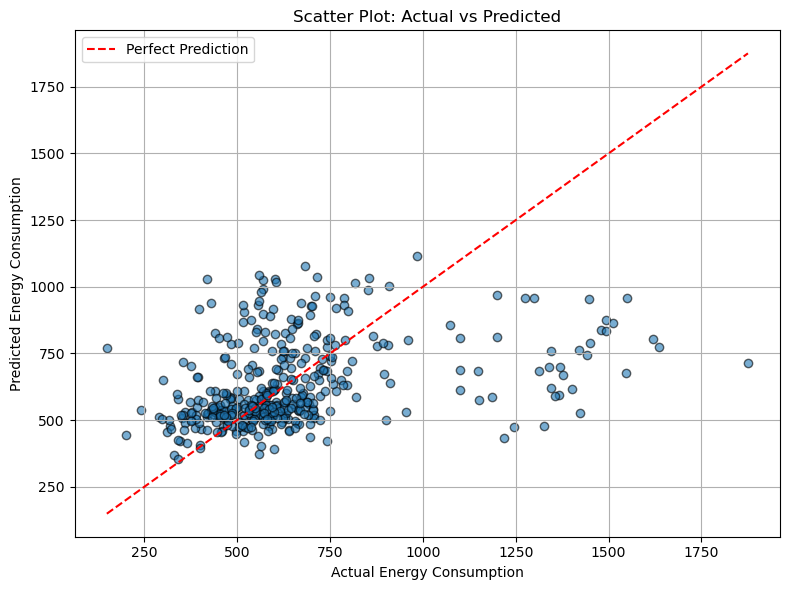

In [14]:
#Scatter Plot: Actual vs Predicted
#This shows the relationship directly — ideally a straight diagonal line:


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction")
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Scatter Plot: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

# Step 1: Get the last 14 days (ending on 2023-07-31)
last_14 = df.loc[:'2023-07-31'].tail(14)
last_day = last_14.iloc[-1]

# Step 2: Construct features for next day (2023-08-01)
next_day_features = {
    'rolling_energy_7d': last_14['energy'].tail(7).mean(),
    'rolling_energy_14d': last_14['energy'].mean(),
    'lag_1_energy': last_day['energy'],
    'day_of_week': (last_day.name + pd.Timedelta(days=1)).dayofweek  # 0=Monday, ..., 6=Sunday
}

# Step 3: Convert to DataFrame
X_new = pd.DataFrame([next_day_features])

# Step 4: Scale using training scaler
X_new_scaled = scaler.transform(X_new)

# Step 5: Predict with Linear Regression
predicted_energy = lr.predict(X_new_scaled)[0]

# Step 6: Output
print(f"🔮 Predicted Energy for 2023-08-01: {predicted_energy:.2f} kWh")


🔮 Predicted Energy for 2023-08-01: 770.63 kWh
